In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import gc

def analyze_dataframe(df, df_name):
    print(f"\n{'='*60}\nIniciando Análise para o DataFrame: {df_name}\n{'='*60}")

    # 1. Shape e dtypes
    print(f"\nShape da tabela de {df_name}: {df.shape}")
    print(f"Colunas da tabela de {df_name} e seus tipos:\n {df.dtypes}")

    # 2. Checando ocorrências de 'NULL'/'null' em colunas object
    print(f"\nVerificando 'NULL'/'null' strings em colunas de texto para {df_name}:")
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        count_null_strings = df[col].isin(['NULL', 'null']).sum()
        print(f"Ocorrências da string 'NULL'/'null' em {col} (no {df_name}): {count_null_strings}")

    # 3. Nulos por coluna
    print(f"\nNúmero de nulos por coluna no {df_name}:\n {df.isnull().sum()}")

    # 4. Registros duplicados
    print(f"\nNúmero de registros duplicados na tabela de {df_name}: {df.duplicated().sum()}")

    # 5. Análise de Datas (Data_Evento)
    if 'Data_Evento' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Data_Evento']):
        print(f"\nLimite inferior das datas de Data_Evento no {df_name}: {df['Data_Evento'].min()}")
        print(f"Limite superior das datas de Data_Evento no {df_name}: {df['Data_Evento'].max()}")

        # 6. Janela de tempo e média de telemetria
        time_window = df['Data_Evento'].max() - df['Data_Evento'].min()
        print(f"Janela de tempo no {df_name}: {time_window}")

        time_window_days = time_window.days + (1 if time_window.seconds > 0 else 0)
        if time_window_days == 0:
            time_window_days = 1
        print(f"Média de telemetria por dia no {df_name}: {round(df.shape[0] / time_window_days, 2)}")

        time_window_hours = time_window_days * 24
        print(f"Média de telemetria por hora no {df_name}: {round(df.shape[0] / time_window_hours, 2)}")
    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'Data_Evento' ou ela não é do tipo datetime. Pulando análises de tempo.")

    # 7. Média de registros por equipamento (se 'TAG' existe)
    if 'TAG' in df.columns:
        registros_por_tag = df.groupby('TAG').size()
        media_registros_por_equipamento = registros_por_tag.mean()
        print(f"\nMédia de registros por equipamento no {df_name}: {media_registros_por_equipamento:.2f}")
    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'TAG'. Pulando média de registros por equipamento.")

    # 8. Distribuição temporal dos registros
    if 'Data_Evento' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Data_Evento']):
        print(f"\n### Distribuição Temporal dos Registros para {df_name}")

        df_plot = df.copy()
        df_plot['Dia'] = df_plot['Data_Evento'].dt.date
        df_plot['Hora'] = df_plot['Data_Evento'].dt.hour

        distribuicao_diaria = df_plot.groupby('Dia').size().reset_index(name='Volume')
        distribuicao_horaria = df_plot.groupby('Hora').size().reset_index(name='Volume')

        plt.figure(figsize=(15, 6))
        sns.lineplot(x='Dia', y='Volume', data=distribuicao_diaria)
        plt.title(f'Volume de Registros de Telemetria por Dia - {df_name}')
        plt.xlabel('Dia')
        plt.ylabel('Volume de Registros')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(15, 6))
        sns.lineplot(x='Hora', y='Volume', data=distribuicao_horaria)
        plt.title(f'Volume de Registros de Telemetria por Hora do Dia - {df_name}')
        plt.xlabel('Hora do Dia')
        plt.ylabel('Volume de Registros')
        plt.xticks(range(0, 24))
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'Data_Evento' ou ela não é do tipo datetime. Pulando plots de distribuição temporal.")


In [10]:
import os

def optimize_dataframe_types(df):

    print(f"\n{'='*60}\nOtimizando tipos de dados para o DataFrame\n{'='*60}")
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Uso de memória inicial: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if str(col_type).startswith('int'):
            # Downcast integer types
            if df[col].min() >= 0:
                # Unsigned integers
                if df[col].max() < 2**8: # 256
                    df[col] = df[col].astype('uint8')
                elif df[col].max() < 2**16: # 65536
                    df[col] = df[col].astype('uint16')
                elif df[col].max() < 2**32: # 4.29e9
                    df[col] = df[col].astype('uint32')
            else:
                # Signed integers
                if df[col].min() > -2**7 and df[col].max() < 2**7 - 1: # -128 to 127
                    df[col] = df[col].astype('int8')
                elif df[col].min() > -2**15 and df[col].max() < 2**15 - 1: # -32768 to 32767
                    df[col] = df[col].astype('int16')
                elif df[col].min() > -2**31 and df[col].max() < 2**31 - 1: # -2.14e9 to 2.14e9
                    df[col] = df[col].astype('int32')
        elif str(col_type).startswith('float'):
            # Downcast float types
            df[col] = df[col].astype('float32')
        elif col_type == 'object':
            # Convert object to category if appropriate
            num_unique_values = len(df[col].unique())
            num_total_values = len(df[col])
            if num_unique_values / num_total_values < 0.5:  # Heuristic: if less than 50% unique values
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Uso de memória final: {end_mem:.2f} MB")
    print(f"Memória economizada: {(start_mem - end_mem):.2f} MB ({((start_mem - end_mem) / start_mem * 100):.2f}%)")
    print(f"{'='*60}\n")
    return df

output_dir = 'drive/MyDrive/hackathon-vale/pre-processado/telemetria/'

def process_telemetry_dataset(path, output_dir):
    df = None
    df_name = path.split('/')[-1]
    base_name, ext = os.path.splitext(df_name)
    output_path = os.path.join(output_dir, f"{base_name}_optimized.parquet")

    print(f"\nProcessing file: {df_name}")

    try:
        if path.endswith('.parquet'):
            df = pd.read_parquet(path)
        elif path.endswith('.xlsx'):
            df = pd.read_excel(path)
        else:
            print(f"Skipping unknown file type for: {df_name}")
            return

        for col_name in ['Data_Evento', 'Inicio_Turno', 'Fim_Turno']:
            if col_name in df.columns:
                try:
                    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
                    print(f"Converted '{col_name}' column to datetime for {df_name}.")
                except Exception as e:
                    print(f"Warning: Could not convert '{col_name}' column to datetime for {df_name}. Error: {e}")
            else:
                print(f"Column '{col_name}' not found in {df_name}. Skipping datetime conversion.")

        if 'Valor' in df.columns:
            try:
                df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')
                print(f"Converted 'Valor' column to numeric for {df_name}.")
            except Exception as e:
                print(f"Warning: Could not convert 'Valor' column to numeric for {df_name}. Error: {e}")
        else:
            print(f"Column 'Valor' not found in {df_name}. Skipping numeric conversion.")

        analyze_dataframe(df, df_name)
        print(f"Analyzed {df_name}.")

        df = optimize_dataframe_types(df)
        print(f"Optimized types for {df_name}.")

        os.makedirs(output_dir, exist_ok=True)
        df.to_parquet(output_path, index=False)
        print(f"Optimized DataFrame saved to: {output_path}")

    except Exception as e:
        print(f"Error processing {df_name}: {e}")

    finally:
        if df is not None:
            del df
            gc.collect()
            print(f"Finished processing and cleared memory for: {df_name}")

### Processando `desenvolver_dontgo.xlsx`


Processing file: desenvolver_dontgo.xlsx
Converted 'Data_Evento' column to datetime for desenvolver_dontgo.xlsx.
Converted 'Inicio_Turno' column to datetime for desenvolver_dontgo.xlsx.
Converted 'Fim_Turno' column to datetime for desenvolver_dontgo.xlsx.
Converted 'Valor' column to numeric for desenvolver_dontgo.xlsx.

Iniciando Análise para o DataFrame: desenvolver_dontgo.xlsx

Shape da tabela de desenvolver_dontgo.xlsx: (147, 19)
Colunas da tabela de desenvolver_dontgo.xlsx e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[ns]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Porte                              object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            objec

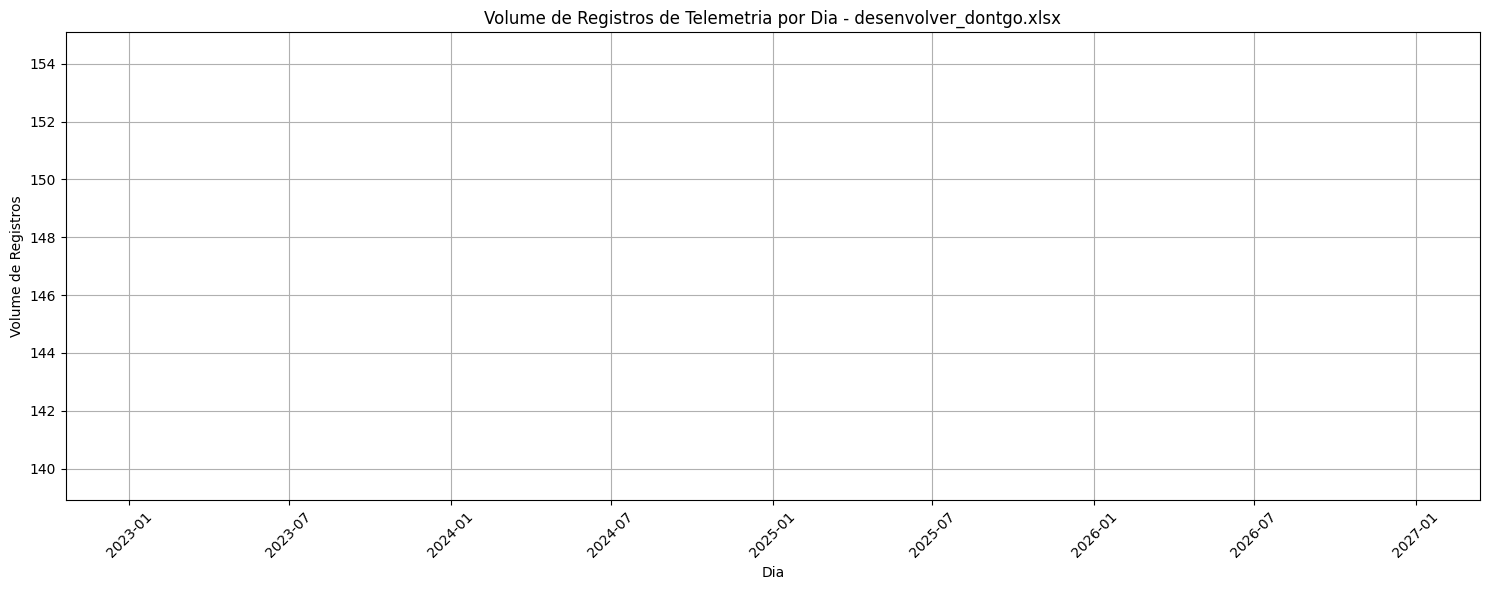

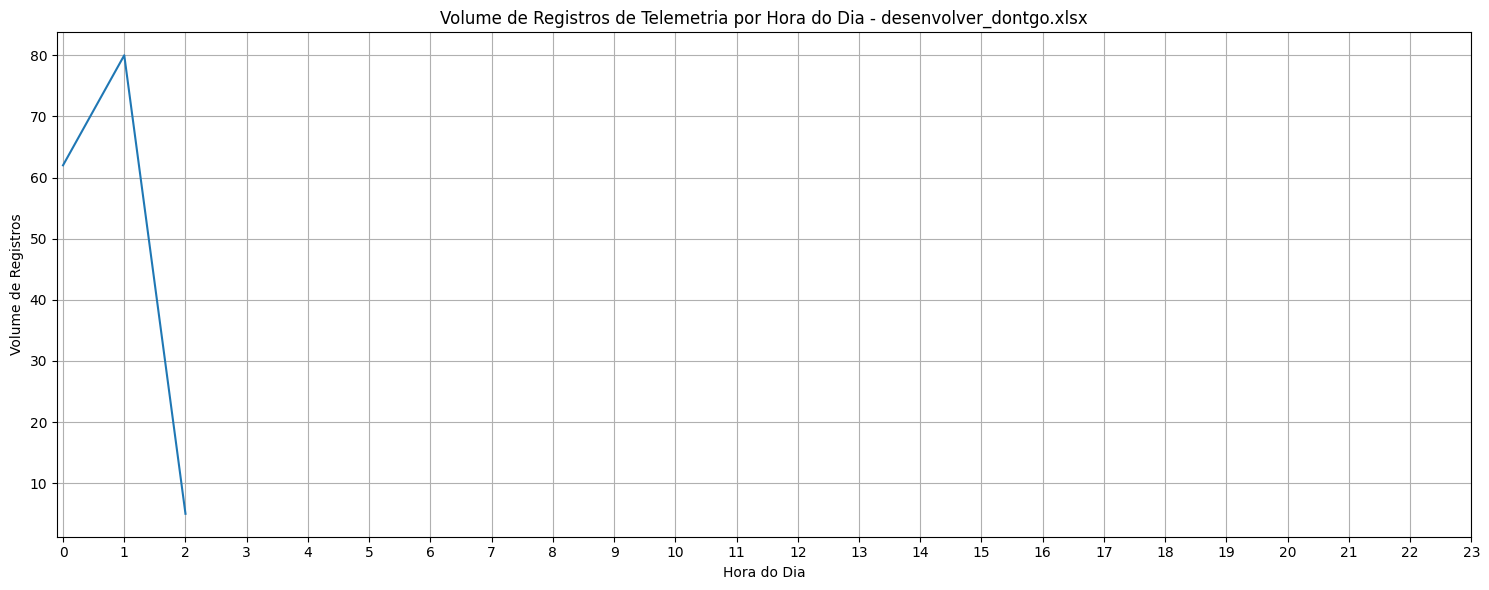

Analyzed desenvolver_dontgo.xlsx.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 0.09 MB
Uso de memória final: 0.01 MB
Memória economizada: 0.08 MB (88.45%)

Optimized types for desenvolver_dontgo.xlsx.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/desenvolver_dontgo_optimized.parquet
Finished processing and cleared memory for: desenvolver_dontgo.xlsx


In [11]:
process_telemetry_dataset(
    '/content/drive/MyDrive/hackathon-vale/telemetria/desenvolver_dontgo.xlsx', output_dir=output_dir)

### Processando `telemetry_jan.parquet`


Processing file: telemetry_jan.parquet
Converted 'Data_Evento' column to datetime for telemetry_jan.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_jan.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_jan.parquet.
Converted 'Valor' column to numeric for telemetry_jan.parquet.

Iniciando Análise para o DataFrame: telemetry_jan.parquet

Shape da tabela de telemetry_jan.parquet: (5400002, 18)
Colunas da tabela de telemetry_jan.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

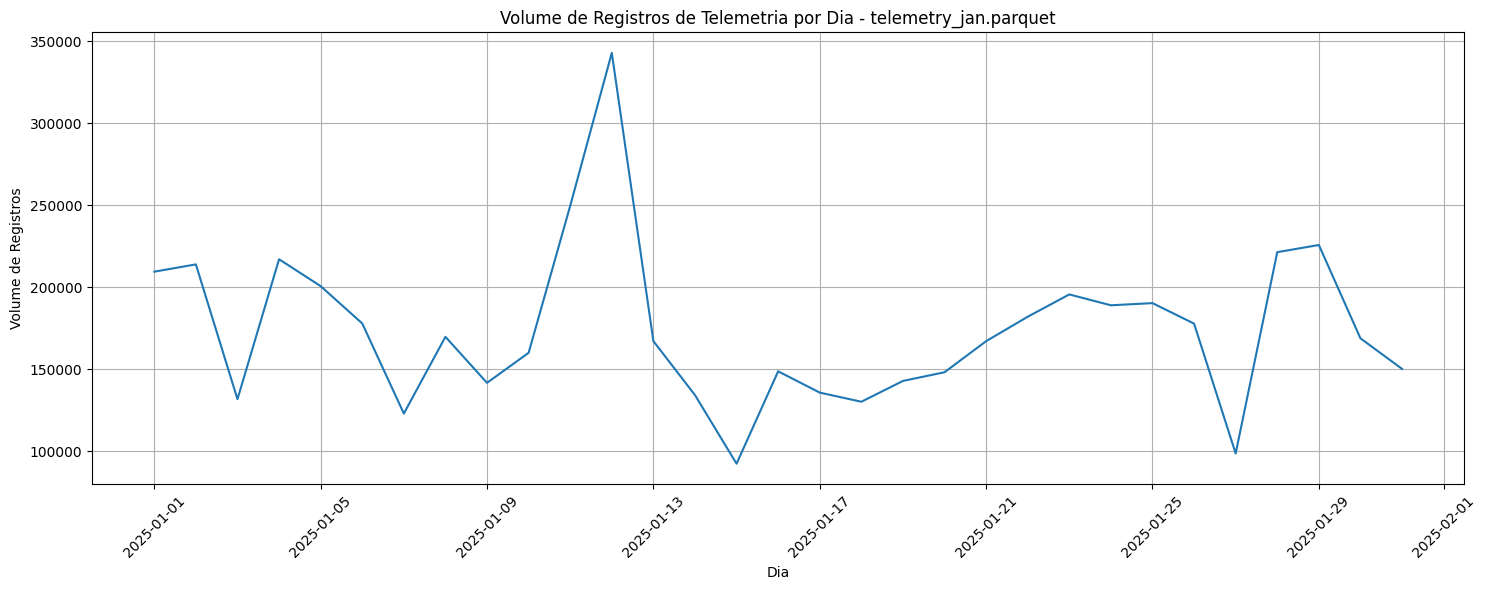

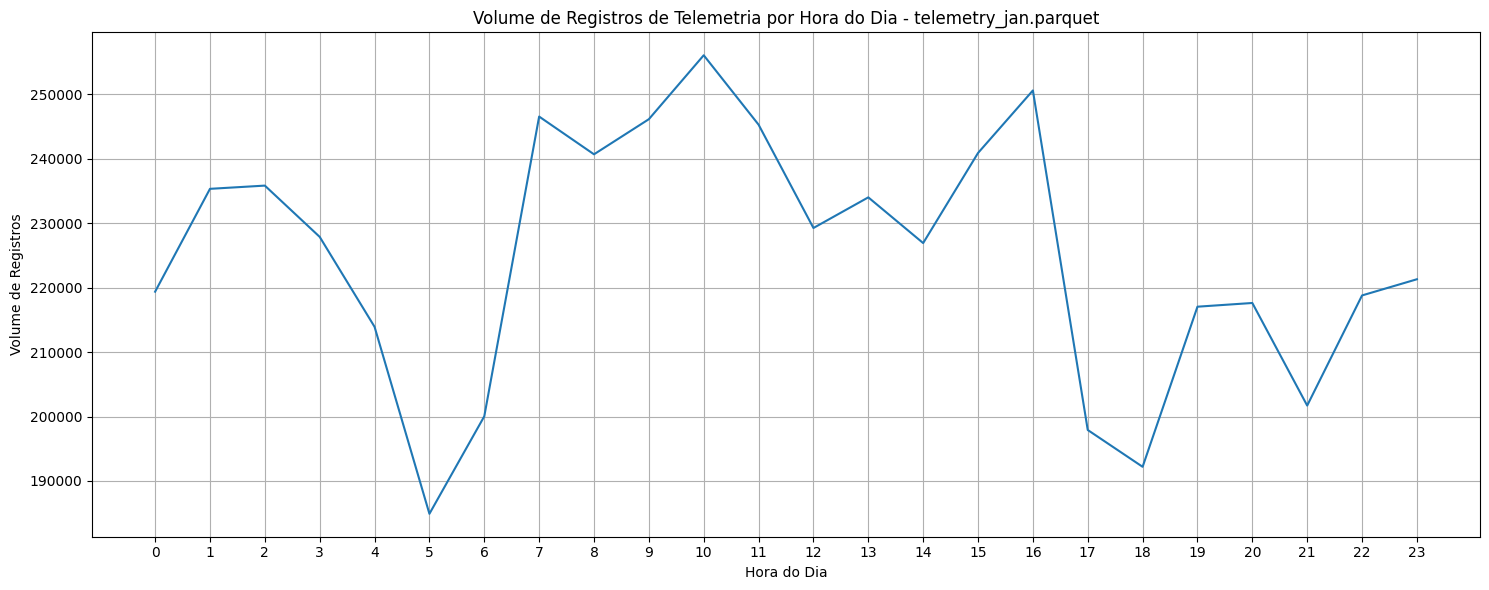

Analyzed telemetry_jan.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 3223.38 MB
Uso de memória final: 262.76 MB
Memória economizada: 2960.62 MB (91.85%)

Optimized types for telemetry_jan.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_jan_optimized.parquet
Finished processing and cleared memory for: telemetry_jan.parquet


In [12]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_jan.parquet', output_dir=output_dir)

### Processando `telemetry_feb.parquet`


Processing file: telemetry_feb.parquet
Converted 'Data_Evento' column to datetime for telemetry_feb.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_feb.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_feb.parquet.
Converted 'Valor' column to numeric for telemetry_feb.parquet.

Iniciando Análise para o DataFrame: telemetry_feb.parquet

Shape da tabela de telemetry_feb.parquet: (5709935, 18)
Colunas da tabela de telemetry_feb.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

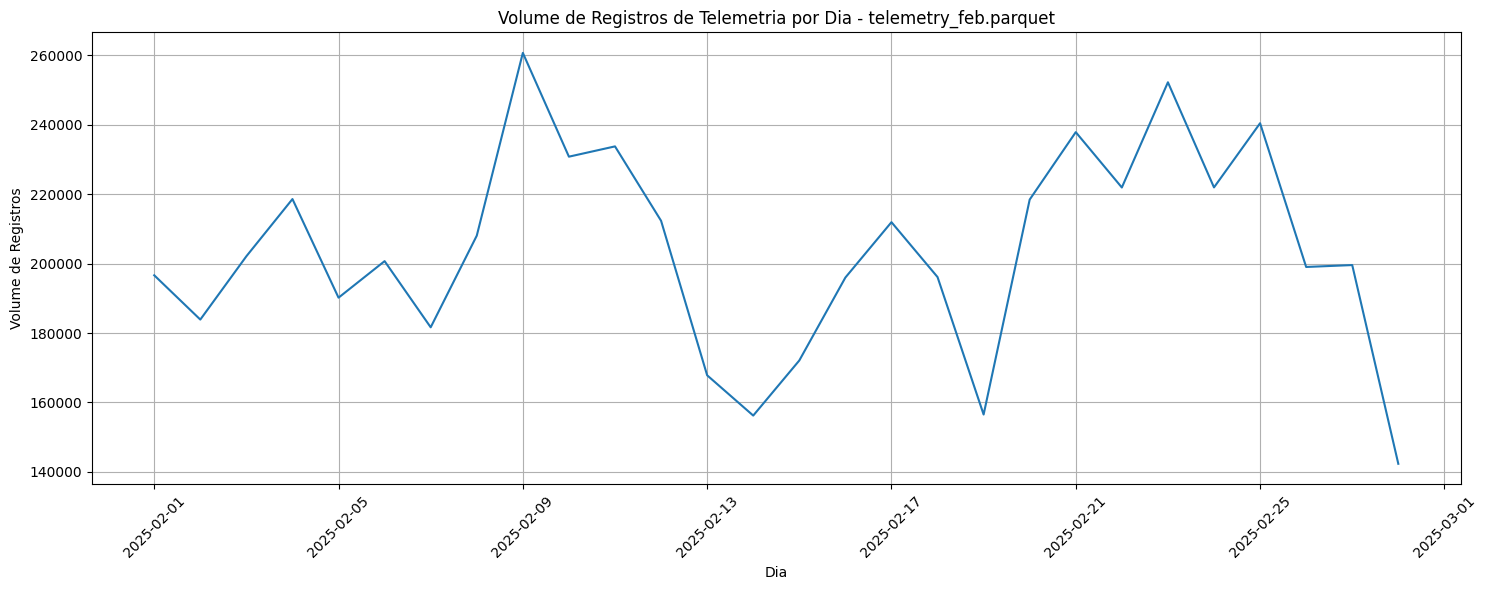

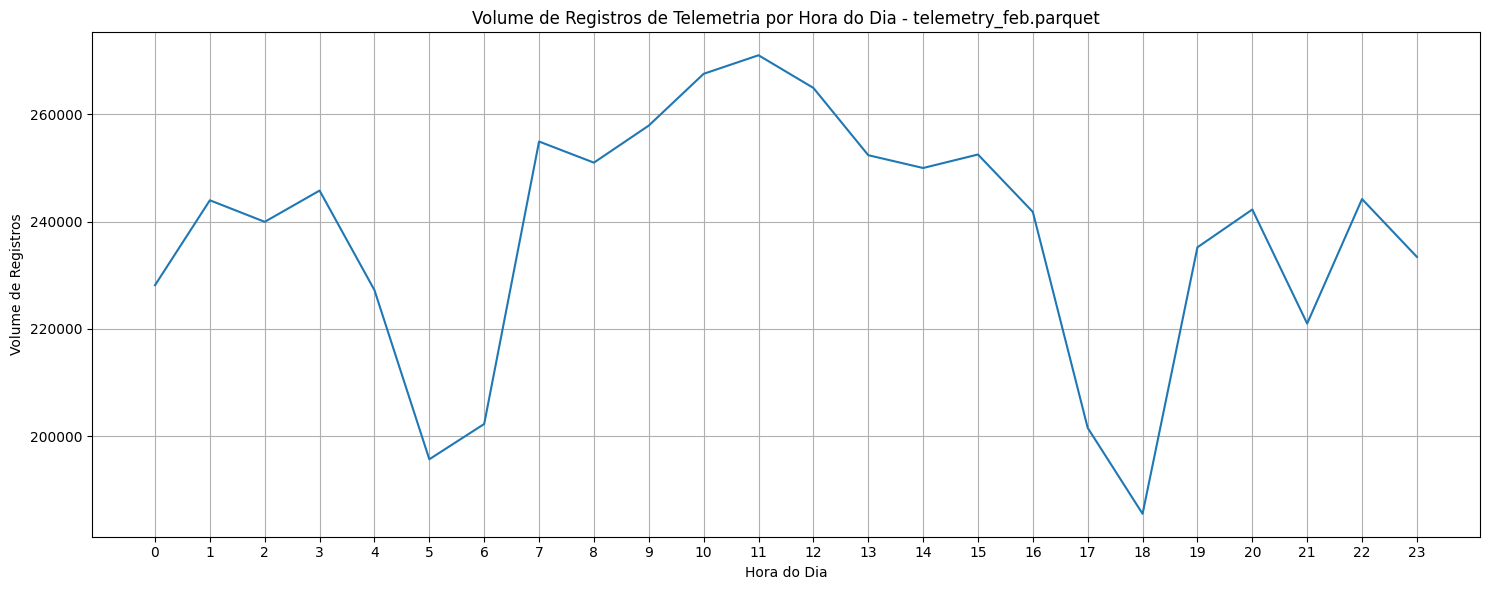

Analyzed telemetry_feb.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 3434.71 MB
Uso de memória final: 277.82 MB
Memória economizada: 3156.89 MB (91.91%)

Optimized types for telemetry_feb.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_feb_optimized.parquet
Finished processing and cleared memory for: telemetry_feb.parquet


In [13]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_feb.parquet', output_dir=output_dir)

### Processando `telemetry_mar.parquet`


Processing file: telemetry_mar.parquet
Converted 'Data_Evento' column to datetime for telemetry_mar.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_mar.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_mar.parquet.
Converted 'Valor' column to numeric for telemetry_mar.parquet.

Iniciando Análise para o DataFrame: telemetry_mar.parquet

Shape da tabela de telemetry_mar.parquet: (5688538, 18)
Colunas da tabela de telemetry_mar.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

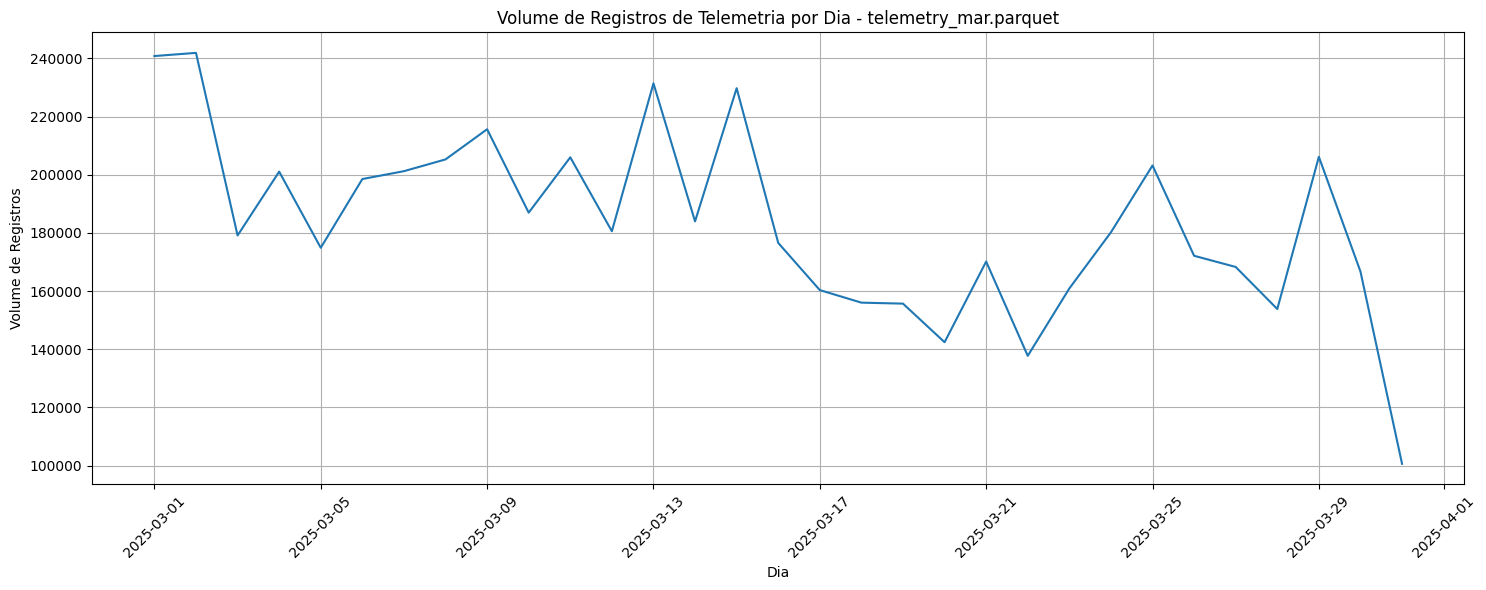

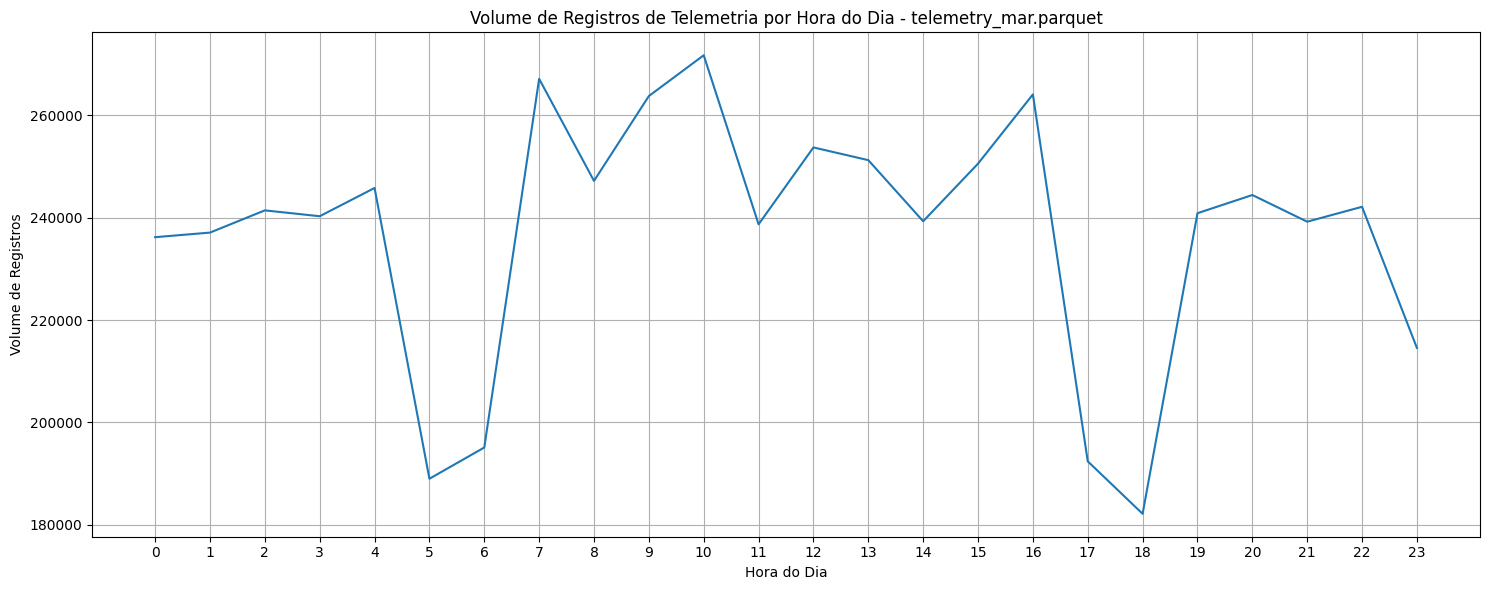

Analyzed telemetry_mar.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 3411.82 MB
Uso de memória final: 276.79 MB
Memória economizada: 3135.04 MB (91.89%)

Optimized types for telemetry_mar.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_mar_optimized.parquet
Finished processing and cleared memory for: telemetry_mar.parquet


In [14]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_mar.parquet', output_dir=output_dir)

### Processando `telemetry_abr.parquet`


Processing file: telemetry_abr.parquet
Converted 'Data_Evento' column to datetime for telemetry_abr.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_abr.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_abr.parquet.
Converted 'Valor' column to numeric for telemetry_abr.parquet.

Iniciando Análise para o DataFrame: telemetry_abr.parquet

Shape da tabela de telemetry_abr.parquet: (6475045, 18)
Colunas da tabela de telemetry_abr.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

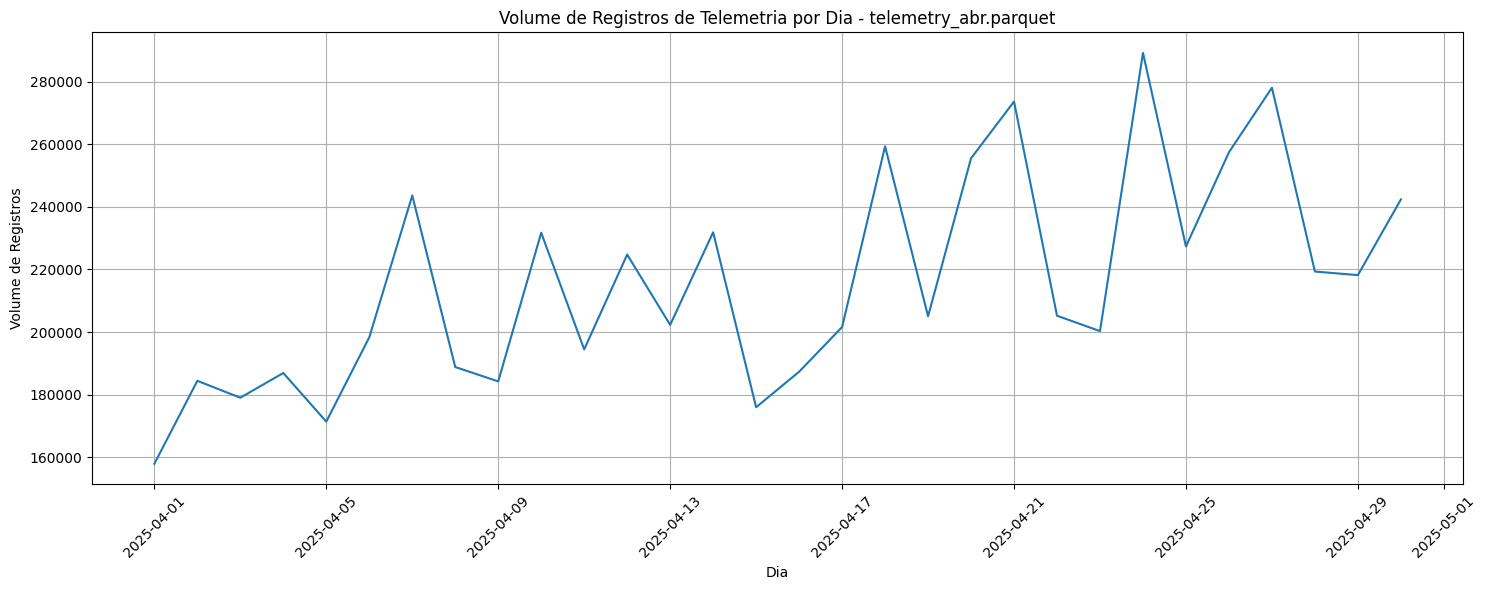

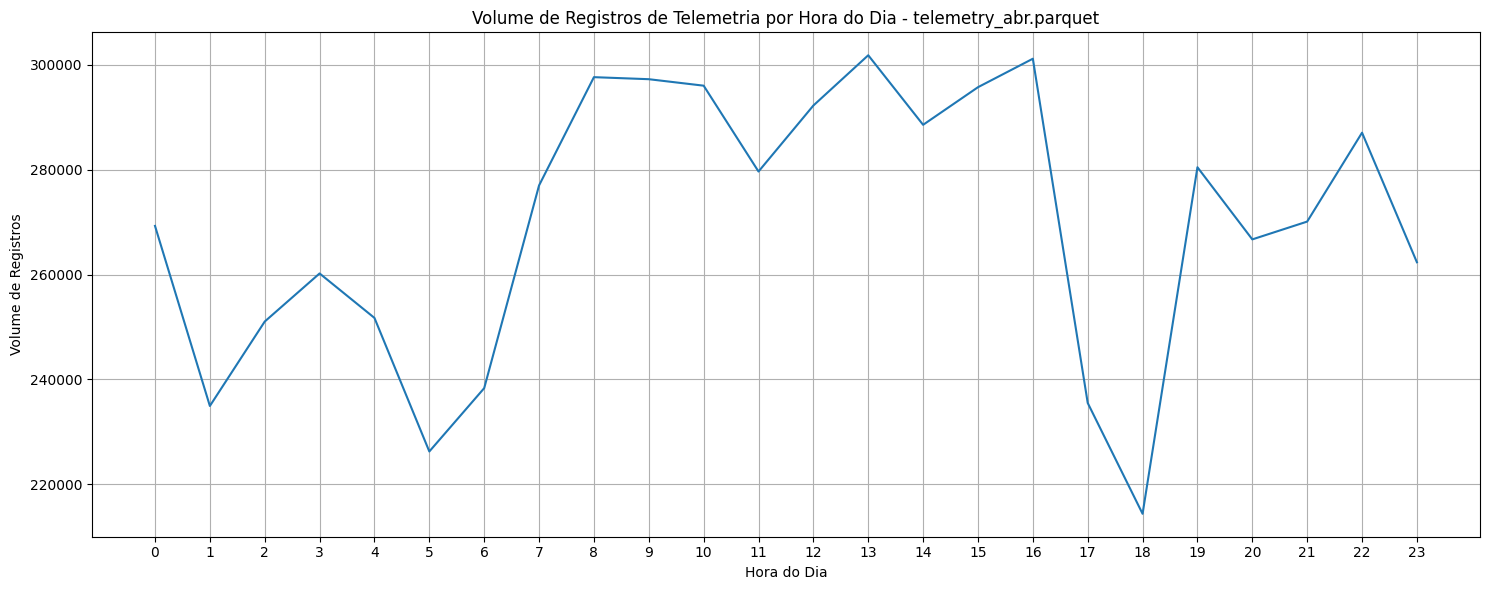

Analyzed telemetry_abr.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 3885.23 MB
Uso de memória final: 315.04 MB
Memória economizada: 3570.19 MB (91.89%)

Optimized types for telemetry_abr.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_abr_optimized.parquet
Finished processing and cleared memory for: telemetry_abr.parquet


In [15]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_abr.parquet', output_dir=output_dir)

### Processando `telemetry_may.parquet`


Processing file: telemetry_may.parquet
Converted 'Data_Evento' column to datetime for telemetry_may.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_may.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_may.parquet.
Converted 'Valor' column to numeric for telemetry_may.parquet.

Iniciando Análise para o DataFrame: telemetry_may.parquet

Shape da tabela de telemetry_may.parquet: (6036291, 18)
Colunas da tabela de telemetry_may.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

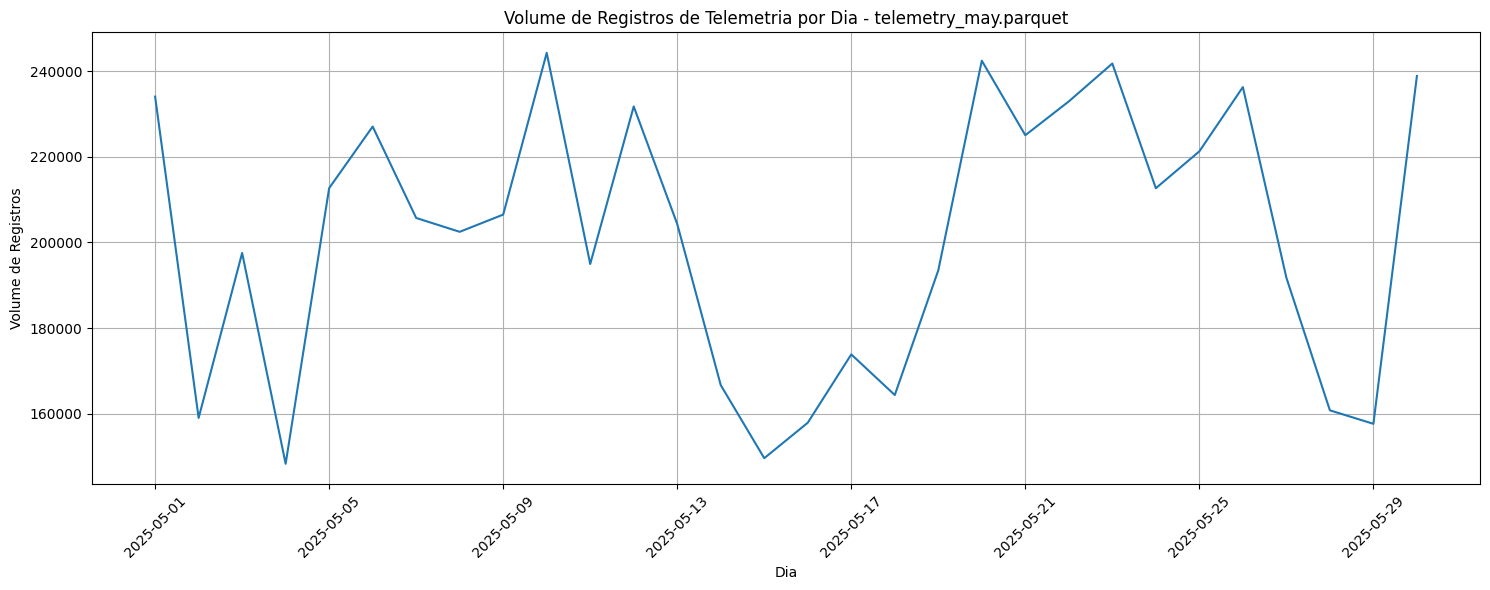

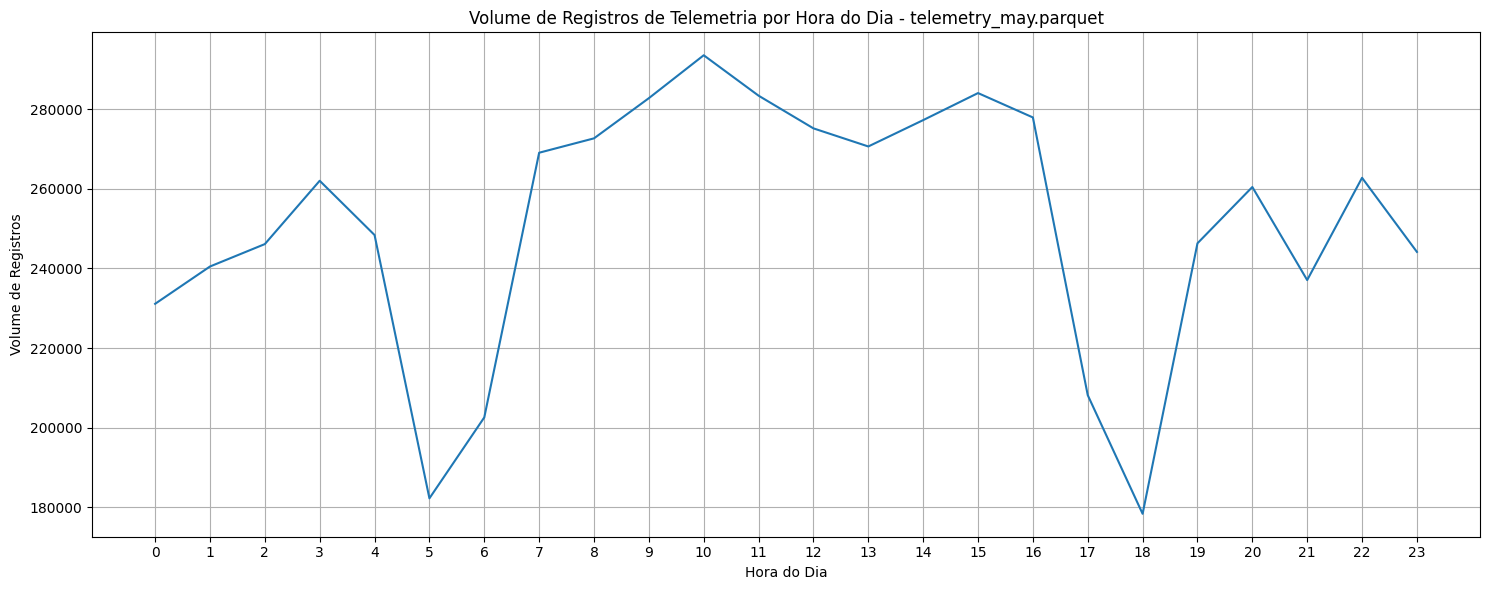

Analyzed telemetry_may.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 3622.55 MB
Uso de memória final: 293.70 MB
Memória economizada: 3328.85 MB (91.89%)

Optimized types for telemetry_may.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_may_optimized.parquet
Finished processing and cleared memory for: telemetry_may.parquet


In [16]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_may.parquet', output_dir=output_dir)

### Processando `telemetry_jun.parquet`


Processing file: telemetry_jun.parquet
Converted 'Data_Evento' column to datetime for telemetry_jun.parquet.
Converted 'Inicio_Turno' column to datetime for telemetry_jun.parquet.
Converted 'Fim_Turno' column to datetime for telemetry_jun.parquet.
Converted 'Valor' column to numeric for telemetry_jun.parquet.

Iniciando Análise para o DataFrame: telemetry_jun.parquet

Shape da tabela de telemetry_jun.parquet: (7854243, 18)
Colunas da tabela de telemetry_jun.parquet e seus tipos:
 Id_Eventos_Telemetria               int64
Data_Evento                datetime64[us]
Inicio_Turno               datetime64[ns]
Fim_Turno                  datetime64[ns]
Dia                                 int64
Localidade                         object
TAG                                object
Tag_Frota                          object
Tipo                               object
Nome_Operador_Anon                 object
Matricula_Operador_Hash            object
Id_Alarme                           int64
Alarme    

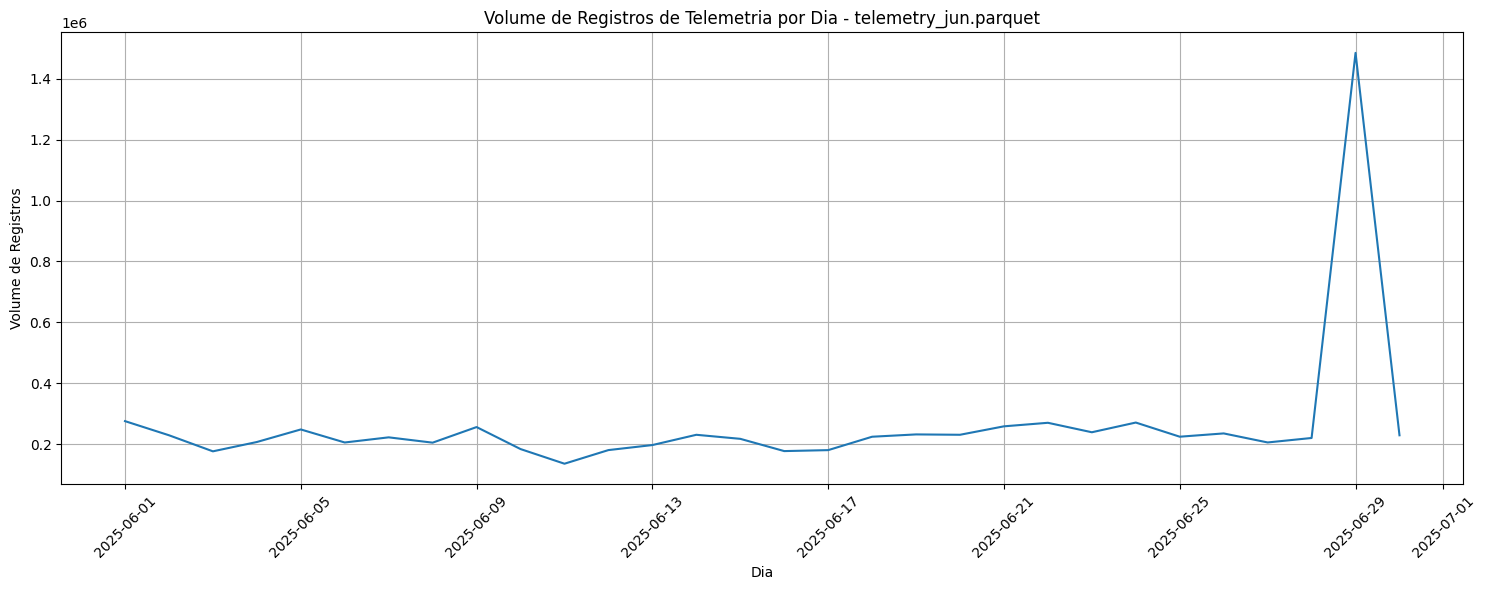

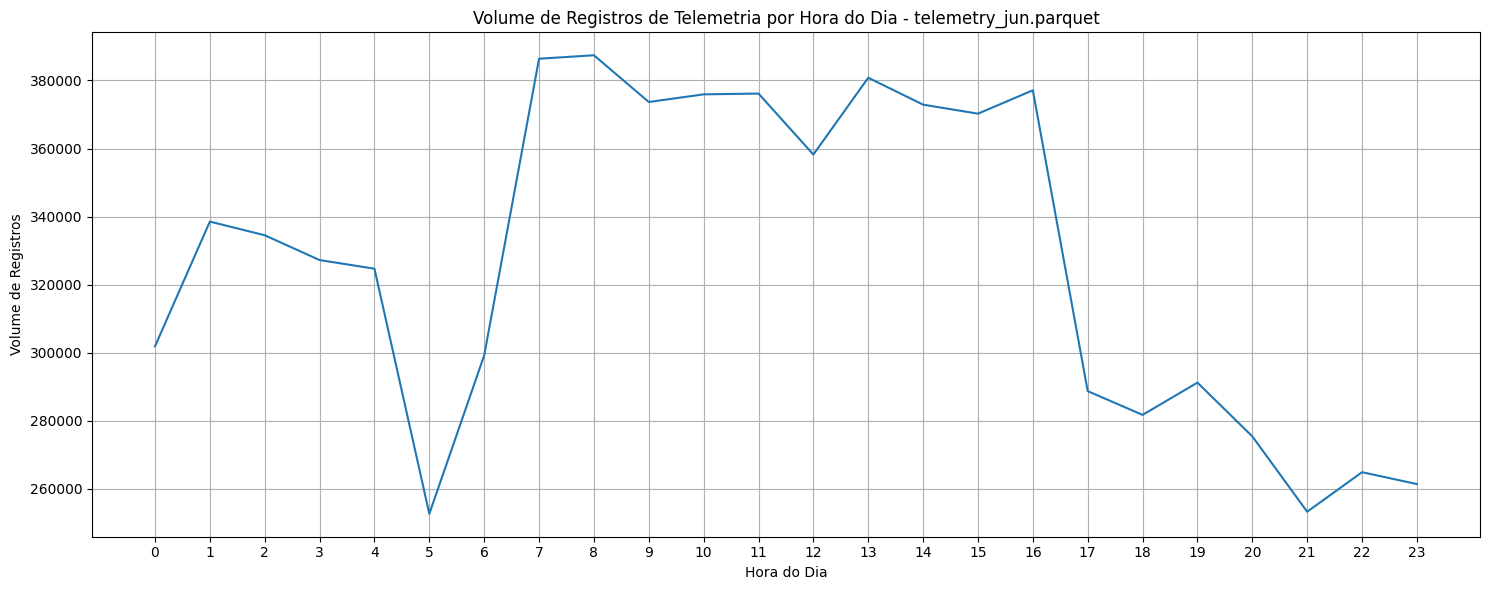

Analyzed telemetry_jun.parquet.

Otimizando tipos de dados para o DataFrame
Uso de memória inicial: 4731.84 MB
Uso de memória final: 382.12 MB
Memória economizada: 4349.71 MB (91.92%)

Optimized types for telemetry_jun.parquet.
Optimized DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_jun_optimized.parquet
Finished processing and cleared memory for: telemetry_jun.parquet


In [17]:
process_telemetry_dataset('/content/drive/MyDrive/hackathon-vale/telemetria/telemetry_jun.parquet', output_dir=output_dir)

### Concatenando todos os DataFrames Otimizados

In [1]:
import pandas as pd
import os
import gc

output_dir = 'drive/MyDrive/hackathon-vale/pre-processado/telemetria/'
final_telemetry_df = None

parquet_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('_optimized.parquet')]

if not parquet_files:
    print("No optimized parquet files found in the output directory.")
else:
    print(f"Found {len(parquet_files)} optimized parquet files. Starting sequential concatenation...")

    for i, file_path in enumerate(parquet_files):
        print(f"Reading and concatenating file {i+1}/{len(parquet_files)}: {file_path}...")
        try:
            df_temp = pd.read_parquet(file_path)
            if final_telemetry_df is None:
                final_telemetry_df = df_temp
            else:
                final_telemetry_df = pd.concat([final_telemetry_df, df_temp], ignore_index=True)

            del df_temp
            gc.collect()
            print(f"Current final DataFrame shape: {final_telemetry_df.shape}")

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    if final_telemetry_df is not None:
        print("\nAll optimized DataFrames concatenated successfully.")
        print(f"Final DataFrame shape: {final_telemetry_df.shape}")
        display(final_telemetry_df.head())

        final_output_path = os.path.join(output_dir, 'final_telemetry.parquet')
        final_telemetry_df.to_parquet(final_output_path, index=False)
        print(f"Final concatenated DataFrame saved to: {final_output_path}")

        del final_telemetry_df
        gc.collect()
        print("Final DataFrame cleared from memory.")
    else:
        print("No DataFrames were successfully concatenated.")


Found 7 optimized parquet files. Starting sequential concatenation...
Reading and concatenating file 1/7: drive/MyDrive/hackathon-vale/pre-processado/telemetria/desenvolver_dontgo_optimized.parquet...
Current final DataFrame shape: (147, 19)
Reading and concatenating file 2/7: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_jan_optimized.parquet...
Current final DataFrame shape: (5400149, 19)
Reading and concatenating file 3/7: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_feb_optimized.parquet...
Current final DataFrame shape: (11110084, 19)
Reading and concatenating file 4/7: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_mar_optimized.parquet...
Current final DataFrame shape: (16798622, 19)
Reading and concatenating file 5/7: drive/MyDrive/hackathon-vale/pre-processado/telemetria/telemetry_abr_optimized.parquet...
Current final DataFrame shape: (23273667, 19)
Reading and concatenating file 6/7: drive/MyDrive/hackathon-vale/pre-pr

,Id_Eventos_Telemetria,Data_Evento,Inicio_Turno,Fim_Turno,Dia,Localidade,TAG,Tag_Frota,Porte,Tipo,Nome_Operador_Anon,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Classe,Is_Dont_Go
0,9371424,2025-01-01 00:05:01.143,2024-12-31 18:00:00,2025-01-01 06:00:00,1,Itabira,CA65924,793-D 4S,Grande Porte,Caminhao,OP_067,H_ce3d6b9eae65,335609875,2nd Tire Tag Timeout,3,Informacional,0.0,NaN,0
1,9371423,2025-01-01 00:05:01.143,2024-12-31 18:00:00,2025-01-01 06:00:00,1,Itabira,CA65924,793-D 4S,Grande Porte,Caminhao,OP_067,H_ce3d6b9eae65,335609862,1st Tire Tag Timeout,3,Informacional,0.0,NaN,0
2,9371430,2025-01-01 00:05:05.257,2024-12-31 18:00:00,2025-01-01 06:00:00,1,Itabira,CA65924,793-D 4S,Grande Porte,Caminhao,OP_067,H_ce3d6b9eae65,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0.0,NaN,0
3,9371429,2025-01-01 00:05:05.257,2024-12-31 18:00:00,2025-01-01 06:00:00,1,Itabira,CA65924,793-D 4S,Grande Porte,Caminhao,OP_067,H_ce3d6b9eae65,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0.0,NaN,0
4,9371428,2025-01-01 00:05:05.257,2024-12-31 18:00:00,2025-01-01 06:00:00,1,Itabira,CA65924,793-D 4S,Grande Porte,Caminhao,OP_067,H_ce3d6b9eae65,335609927,6th Tire Tag Timeout,3,Informacional,0.0,NaN,0


Final concatenated DataFrame saved to: drive/MyDrive/hackathon-vale/pre-processado/telemetria/final_telemetry.parquet
Final DataFrame cleared from memory.
